# Script for embryo segmentation and staging analysis walkthrough 



This script walks through the **full pipeline** for embryo segmentation and age staging, while recording relevant information into a central CSV (`embryos.csv`). The pipeline performs:

1. **ND2 → TIF conversion** (extracts metadata, creates max-projection images, logs failing files),
2. **Stardist-based segmentation** (produces mask predictions),
3. **Mask-based cropping** of individual embryos (stores each embryo stack + mask),
4. **Stage prediction** using a Keras/TensorFlow model,
5. **CSV updates** at each step (channels, bounding boxes, status flags, etc.).

Below is an overview of required folders, files, and how each step interacts with them.

---

## Required Folders

You’ll need the following folders under your **pipeline** (master) directory:

- **`nd2_temp_files`**  
  Contains the **new ND2 files** to process. During the pipeline, each ND2 is converted, and the ND2 is then **deleted** to save space (so make sure you only keep copies here, not your originals).
- **`maxp_gfp_temp_files`**  
  Holds **GFP max-projection** images (used by the Stardist segmentation step).
- **`tif_temp_files`**  
  Holds **TIF stacks** converted from ND2, plus potential intermediate data.

Additional folders get created or used as you progress in the pipeline (e.g., `finaldata_temp_files`, `dapi`, `preview_embryos`, etc.), depending on the scripts.

---

## Required Files

Inside the **pipeline** directory, ensure these files exist (some are updated during the run):

- **`channel_to_channel_type.csv`**  
  Maps channel names (e.g., “Cy5”) to smFISH labels (“dpy23.ex” etc.). 
- **`embryos.csv`**  
  The central CSV tracking each processed embryo. Fields like original filename, cropped TIF, mask files, channels, stage, etc. are appended or updated by each pipeline step.
- **`failing_nd2toTiff_files_and_rejected.txt`**  
  A simple text file where any ND2 that fails conversion (or is skipped due to missing metadata) is recorded. If an ND2 is incomplete or has fewer than 4 channels, it’s also listed here.

---

## How the Script Works

1. **Run ND2 → TIF**:  
   The first stage reads every `.nd2` in `nd2_temp_files`, converts it to `.tif`, extracts metadata, and writes rows to `embryos.csv`. If any ND2 fails, its name is appended to `failing_nd2toTiff_files_and_rejected.txt`.

2. **Stardist Predict**:  
   Uses the **GFP max-projections** in `maxp_gfp_temp_files` to predict binary masks, saved in a `.npz` file (`predicted_masks_and_filenames.npz`).

3. **Make Masked Embryos**:  
   Loads those mask predictions, finds bounding boxes, **updates the CSV** to create “cropped” embryo rows, and saves the cropped stacks in `finaldata_temp_files`.

4. **Stage Prediction**:  
   A Keras model is used to classify each embryo (based on DAPI stack), and the CSV is updated with “predicted_bin” fields.

At each step, the **CSV** is either extended or updated, ensuring the pipeline can be paused or resumed.

---

## Usage

1. **Activate** the conda environment:
   ```bash
   conda env create -f environment.yml
   conda activate embryo-pipeline

2. Place **new ND2 files** in nd2_temp_files.   

3. Run the master script (or each step individually) in order:
  - python nd2_to_tif.py
  - python stardist_predict.py
  - python make_masked_previews.py
  - python stage_prediction.py

4. Check embryos.csv and your output folders for results:
- maxp_gfp_temp_files → GFP max-proj images
- predicted_masks_and_filenames.npz → Stardist masks
- finaldata_temp_files → Cropped embryo stacks, masks, previews
- embryos.csv → Updated with bounding boxes, channels, stage predictions

## Step 1: Load ND2 Image and Save as TIFF, Record Metadata in `embryos.csv`

The first step prepares new `.nd2` files for subsequent processing. It does the following:

1. **Read ND2**: 
   - Handles both single-image and multi-position `.nd2` files containing embryos.
   - Checks that the file has the **expected channel order**:
     1. **smFISH**  
     2. **smFISH**  
     3. **smFISH**  
     4. **GFP**  
     5. **DAPI**  
   - Logs any missing or incomplete channels to `failing_nd2toTiff_files_and_rejected.txt` and skips those files.

2. **Save TIFF & Max-Proj**:
   - Converts each ND2 into a temporary 4D **TIFF stack** (dimensions: Z, channels, Y, X) stored in `tif_temp_files`. 
   - Extracts **channel metadata** (DAPI, GFP, etc.) and writes it to `embryos.csv`.
   - Creates a **GFP maximum projection** for each file (stored in `maxp_gfp_temp_files`), later used in embryo segmentation.

3. **Update CSV & Logging**:
   - Appends a row to `embryos.csv` for each ND2 file (or each series/position) with fields like:
     - **`filename`**: Base name of the output TIFF
     - **Channel info** (`c0`, `c1`, etc.) 
     - **DAPI/GFP channel indices**, number of Z-planes, etc.
   - Looks up channel types (gene names, etc.) via `channel_to_channel_type.csv` to categorize smFISH channels by gene or condition.
   - Writes diagnostic information to `pipeline.log`, including any ND2 that fails or any unexpected channel layouts.

4. **Filename Convention**:
   - Typically, ND2 filenames start with a date, the worm strain, an optional RNAi condition, and the mRNAs targeted by smFISH. 
   - The script parses these name tokens to label the output TIFF and update `embryos.csv` fields accordingly.

By the end of **Step 1**, you have:
- A **TIFF stack** for each ND2 (in `tif_temp_files`),
- **GFP max-projections** (in `maxp_gfp_temp_files`),
- Updated entries in `embryos.csv` describing each converted file,
- Errors/failures noted in `failing_nd2toTiff_files_and_rejected.txt` and `pipeline.log`.

In [ ]:
import os
from nd2_to_tif import run_nd2_to_tif

# Define your paths here:
pipeline_dir = 'E:\pipeline'
log_file_path = os.path.join(pipeline_dir, 'pipeline.log')
channels_csv_path = os.path.join(pipeline_dir, 'channel_to_channel_type.csv')
failing_nd2_list_file = os.path.join(pipeline_dir, "failing_nd2toTiff_files_and_rejected.txt")
csv_path = os.path.join(pipeline_dir, 'embryos.csv')
dir_path_nd2 = os.path.join(pipeline_dir, 'nd2_temp_files')
dir_path_tif = os.path.join(pipeline_dir, 'tif_temp_files')
dir_path_maxp_gfp = os.path.join(pipeline_dir, 'maxp_gfp_temp_files')

# Run the pipeline
run_nd2_to_tif(
    pipeline_dir=pipeline_dir,
    log_file_path=log_file_path,
    channels_csv_path=channels_csv_path,
    failing_nd2_list_file=failing_nd2_list_file,
    csv_path=csv_path,
    dir_path_nd2=dir_path_nd2,
    dir_path_tif=dir_path_tif,
    dir_path_maxp_gfp=dir_path_maxp_gfp
)

(91, 5, 1024, 1024)


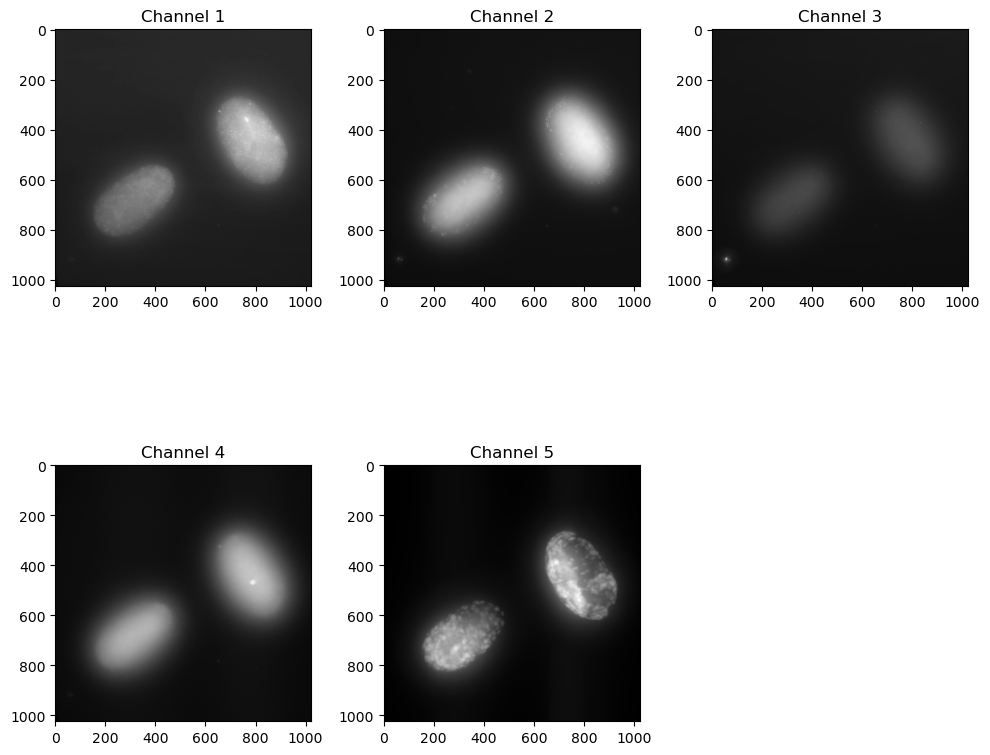

In [ ]:
# Show example image of the tif files
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np

# Load the tiff file from the folder
tif_file_path = os.path.join(dir_path_tif, 'CB428_925.tif')
tif_file = tiff.imread(tif_file_path)
#Show dimensions of the tif file
print(tif_file.shape)

# Show the image with all 5 channels (dimension 2) split as z max projection (dimension 1)
plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(np.max(tif_file[:, i, :, :], axis=0), cmap='gray')
    plt.title(f'Channel {i+1}')
    plt.tight_layout()
plt.show()


## Step 2: Predict Embryo Masks with StarDist

In this step, the **GFP max-projection** from Step 1 is used to predict embryo outlines. We apply a **StarDist** model trained specifically for **embryo segmentation**, generating a binary mask of each embryo in the field of view.

1. **Load GFP Images**  
   We scan `maxp_gfp_temp_files` for any new GFP max-projection images (created in Step 1). Each image is **normalized** or rescaled so that StarDist can reliably detect embryo boundaries.

2. **Run StarDist2D**  
   - A pre-trained **StarDist** model (stored in the `stardist` subfolder) is loaded. 
   - It predicts an **instance segmentation** for each GFP max-projection, producing labeled embryo regions.

3. **Save Predicted Masks**  
   - The resulting label masks (and corresponding image filenames) are temporarily saved into a **NumPy `.npz`** file (e.g., `predicted_masks_and_filenames.npz`). 
   - This file holds:
     - **`labels`**: a stack of 2D label images (one per GFP max-projection)
     - **`names`**: the matching image filenames
   - The `.npz` is used in **Step 3** to actually crop the embryo regions.

4. **Logging & Model Details**  
   - Processing details are written to `pipeline.log`, including any issues with dimension mismatches or missing images. 

By the end of **Step 2**, each GFP max-projection has a corresponding **mask** of embryo outlines, ready to guide cropping in the next step.

In [ ]:
from stardist_predict import run_stardist_predict
import os

pipeline_dir = 'E:\pipeline'

# Define your parameters and paths here:
dir_path_maxp_gfp = os.path.join(pipeline_dir, 'maxp_gfp_temp_files')
predicted_npz_path = os.path.join(pipeline_dir, 'predicted_masks_and_filenames.npz')
log_file_path = os.path.join(pipeline_dir, 'pipeline.log')

# Optionally, define custom sizes for the down- and upscaling:
img_size_down = 512
img_size_up = 1024

# Run the pipeline
run_stardist_predict(
    dir_path_maxp_gfp=dir_path_maxp_gfp,
    predicted_npz_path=predicted_npz_path,
    log_file_path=log_file_path,
    cleanup=False,                # whether to remove the GFP directory afterwards
    img_size_down=img_size_down, 
    img_size_up=img_size_up,
    stardist_model_name='stardist',
    stardist_model_basedir='E:\pipeline'
)


## Step 3: Create Individual Embryo Cropped Images, Masks, and Preview Images

In this step, the **predicted masks** from Step 2 (stored in the `.npz` file) are used to isolate each embryo within the original TIFF. We generate:

1. **Cropped Embryo Stacks**  
   - For each label in the StarDist mask, the script computes bounding boxes (padding as needed) and **crops** the corresponding region from the full 4D TIFF (in `tif_temp_files`).
   - If multiple embryos are found in a single TIFF, the row in `embryos.csv` is **duplicated**, each with a new `cropped_image_file` name. 
   - A separate **DAPI stack** is also saved for each cropped embryo, which is essential for the **stage prediction** in Step 4.

2. **Embryo Masks**  
   - Each label region in the mask is saved as a binary image (0 for background, 255 for embryo). 
   - These masks are stored in `finaldata_temp_files/masks`, aligning with the cropped embryo files in `finaldata_temp_files/tifs`.

3. **Median Filtered smFISH** (optional)  
   - For each embryo, the script may create median-subtracted images of the smFISH channels (helpful for later spot detection, e.g., with RS-FISH).
   - These **median-filtered** results are saved in `finaldata_temp_files/medians`.

4. **Preview Images**  
   - To quickly **flag** broken or partial embryos, a **combined “preview”** is saved to `preview_embryos`:
     - **Top-left**: DAPI max-projection
     - **Top-right**: Binary embryo mask
     - **Bottom-left**: First smFISH mean-projection
     - **Bottom-right**: Second smFISH (or another channel)
   - The preview PNG makes it easy to see if an embryo is valid or truncated.

5. **CSV Updates**  
   - For each embryo bounding box, a new row is appended (or the existing row is duplicated) in `embryos.csv`, with fields like:
     - **`cropped_image_file`**: The cropped embryo TIFF
     - **`cropped_mask_file`**: The matching mask
     - **Bounding box coords** (e.g., `crop_offset_x`, `crop_offset_y`)
     - **Status** set to `0` for newly cropped embryos

By the end of **Step 3**, each embryo has:
- A **cropped 4D stack** (in `finaldata_temp_files/tifs`),
- A **binary mask** (in `finaldata_temp_files/masks`),
- A **DAPI-only stack** for stage prediction (in `dapi` folder),
- An optional **median-filtered** smFISH image (in `finaldata_temp_files/medians`),
- A **preview** for quick visual inspection (in `preview_embryos`),
- Updated entries in `embryos.csv` marking each embryo’s location and files.


In [ ]:
from make_masked_previews import run_make_masked_embryos_and_previews
import os

# Define your paths
pipeline_dir = 'E:\pipeline'

csv_path = os.path.join(pipeline_dir, 'embryos.csv')
dir_path_tif = os.path.join(pipeline_dir, 'tif_temp_files')
dir_path_finaldata = os.path.join(pipeline_dir, 'finaldata_temp_files')
dir_dapi = os.path.join(pipeline_dir, 'dapi')
dir_preview = os.path.join(pipeline_dir, 'preview_embryos')
predicted_npz_path = os.path.join(pipeline_dir, 'predicted_masks_and_filenames.npz')
log_file_path = os.path.join(pipeline_dir, 'pipeline.log')

# Optionally adjust filter_size, pad_embryo_size, etc.
run_make_masked_embryos_and_previews(
    pipeline_dir=pipeline_dir,
    csv_path=csv_path,
    dir_path_tif=dir_path_tif,
    dir_path_finaldata=dir_path_finaldata,
    dir_dapi=dir_dapi,
    dir_preview=dir_preview,
    predicted_npz_path=predicted_npz_path,
    log_file_path=log_file_path,
    filter_size=19,
    pad_embryo_size=40
)


## Step 4: Run Stage Prediction

In this final step, **DAPI** images—cropped embryos saved in Step 3—are used to predict the developmental stage of each embryo.

1. **Load & Preprocess DAPI**  
   - Each **cropped DAPI stack** (e.g., 20 slices around the embryo’s midpoint) is read from `dapi/`. 
   - The script optionally pads/crops the DAPI to a consistent region (e.g., remove 40 px borders).
   - This yields a standardized 3D stack per embryo, centered on the middle Z-slices.

2. **Tile Generation & Augmentation**  
   - Each DAPI stack is subdivided into **tiles** of size (e.g.) `64×64` or `128×128`.  
   - **Data augmentation** (flip, rotation, shear, brightness, etc.) is applied to boost the number of tiles.  
   - This step produces multiple augmented “2D slices” or “tiles” per embryo, saved to a temporary directory.

3. **Model Inference**  
   - A **Keras/TensorFlow** model (trained at [XX location]) is loaded. It expects the same tile size as training.  
   - For each embryo, all tiles are **predicted** individually. The script obtains a classification label (e.g., stage bin 1, 2, 3, etc.) for each tile.

4. **Majority Vote**  
   - Since a single embryo can generate many tiles (and each tile has a predicted class), the script applies a **majority vote** to determine the embryo’s overall stage.  
   - Additional metrics like the ratio of votes for the winning class or average prediction probability might be recorded.

5. **Update Embryos.csv**  
   - The **`predicted_bin`** field (or a similar column) is updated in `embryos.csv` to reflect the majority-vote stage.  
   - Confidence scores or tile-level details can also be logged, aiding in downstream QC.

By the end of **Step 4**, each embryo’s DAPI stack has been classified into a **stage bin**, fully recorded in your master CSV. The pipeline is thus complete for **embryo segmentation** (Steps 1–3) and **stage prediction** (Step 4).

In [ ]:
from stage_prediction import run_stage_prediction
import os

pipeline_dir = 'E:\pipeline'
csv_path = os.path.join(pipeline_dir, 'embryos.csv')
log_file_path = os.path.join(pipeline_dir, 'pipeline.log')
stage_prediction_model_and_weights_path = os.path.join(pipeline_dir, 'staging_model\stage_bin_fullmodel_MODELandWEIGHTS_after100epochs_big_adam_drop0.03_imsize128_period20_batch64.h5')

run_stage_prediction(
    pipeline_dir=pipeline_dir,
    csv_path=csv_path,
    log_file_path=log_file_path,
    stage_prediction_model_and_weights_path=stage_prediction_model_and_weights_path,
    new_nslices=20,       # how many Z-slices to keep (centered)
    pad_xy=40,            # how many px to crop from each XY edge
    tile_size=64,
    n_augment_slices=5,
    batch_size=20
)


## Step 5: Add imagej metadata - so that images will open with channel seperation.

Use the script XX to run over the folder XX to change the metadata of the files. 

## Step 6: Copy all images and csv to data server.

In step 6 all processed files are copied to the final location. 

In [ ]:
from copy_to_data import run_copy_to_data
import os

pipeline_dir = 'X:\Wu_Lab-Vutara\Experiments\Laura\smFISH\pipeline_smFISH'

scratch_csv_path = os.path.join(pipeline_dir, 'embryos.csv')
dir_path_scratch_finaldata = os.path.join(pipeline_dir, "finaldata_temp_files")
dir_path_scratch_preview = os.path.join(pipeline_dir, "preview_embryos")

dir_path_new_tif = os.path.join(pipeline_dir, 'tif_temp_files')
dir_path_new_nd2 = os.path.join(pipeline_dir, 'nd2_temp_files')

analysis_path = 'X:\Wu_Lab-Vutara\Experiments\Laura\smFISH\\pipeline_smFISH\\final'
log_file_path = os.path.join(pipeline_dir, 'pipeline.log')

run_copy_to_data(
    pipeline_dir=pipeline_dir,
    scratch_csv_path=scratch_csv_path,
    dir_path_scratch_finaldata=dir_path_scratch_finaldata,
    dir_path_scratch_preview=dir_path_scratch_preview,
    dir_path_new_tif=dir_path_new_tif,
    dir_path_new_nd2=dir_path_new_nd2,
    analysis_path=analysis_path,
    log_file_path=log_file_path
)
